<a href="https://colab.research.google.com/github/SilasDetering/SilasBA/blob/main/Silas_BA_Graphen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
from google.colab import files, drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit

In [33]:
# Datei hochladen
uploaded = files.upload()
file_name = next(iter(uploaded))

Saving Messung0901-1-2.xlsx to Messung0901-1-2 (1).xlsx


# 1.0 Raw RSSI and Kalmanfiltered RSSI für bestimmte Distanz (old)

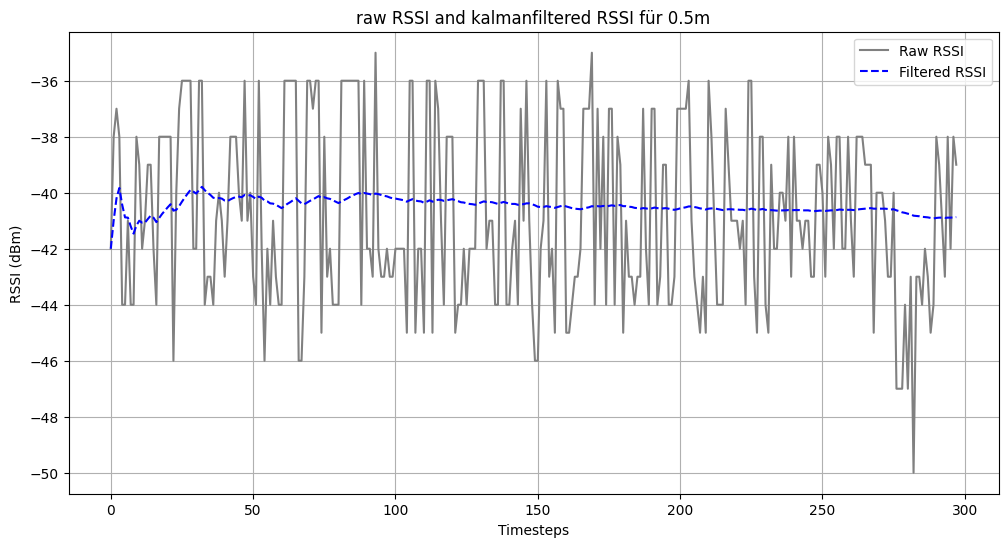

In [3]:
df = pd.read_excel(file_name, header=1)
df = df[['TimeStep', 'RAW', 'KALMAN']]

# Reale Distanz als konstante festlegen
real_distance = 0.5

# Graphen erstellen
plt.figure(figsize=(12, 6))

# Plot für RSSI
plt.plot(df.index, df['RAW'], label='Raw RSSI', linestyle='-', color='gray')

# Plot für gefilterten RSSI
plt.plot(df.index, df['KALMAN'], label='Filtered RSSI', linestyle='--', color='blue')

plt.ylabel('RSSI (dBm)')
plt.xlabel('Timesteps')

# Zweite Y-Achse für die Distanz
# dist_ax = plt.gca().twinx()
# dist_ax.plot(df.index, df['Distance'], label='Distance', color='green', linestyle='--')

# Reale Distanz als konstante Linie hinzufügen
# dist_ax.axhline(y=real_distance, color='red', linestyle=':', label='Real Distance')

# Achsentitel und Beschriftungen setzen
# dist_ax.set_ylabel('Distance (m)')

plt.legend()
plt.grid()
plt.title('raw RSSI and kalmanfiltered RSSI für ' + str(real_distance) + 'm')

plt.show()


# 1.1 Hig Fluctuation Filter für bestimmte Distanz (old)

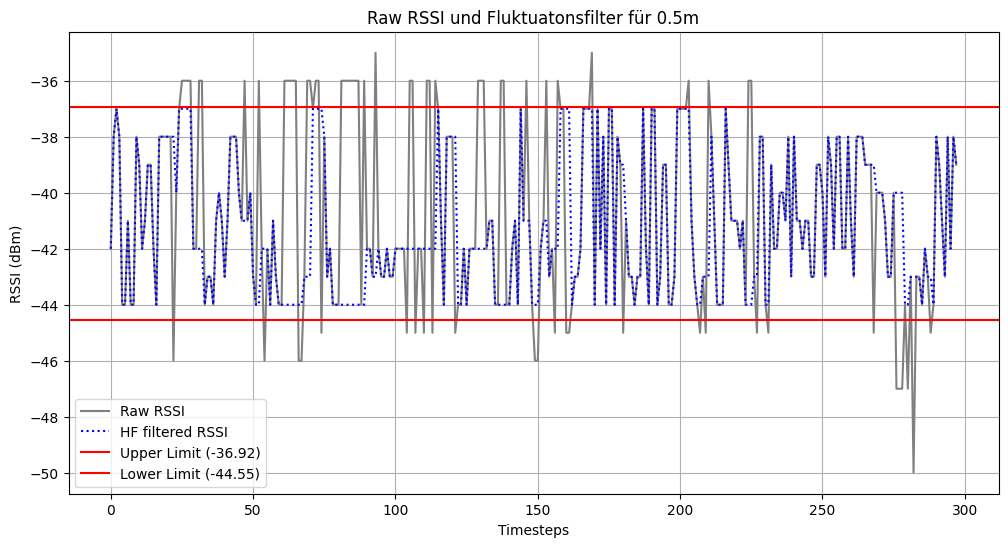

In [4]:
df = pd.read_excel(file_name, header=1)
df = df[['TimeStep', 'RAW', 'KALMAN']]

# Berechnung des Mittelwerts und der Standardabweichung der RSSI-Werte
mean_rssi = df['RAW'].mean()
std_rssi = df['RAW'].std()

# Berechnung der Limits (Fluktuationsfilter)
upper_limit = mean_rssi + (1.2 * std_rssi)
lower_limit = mean_rssi - (1.2 * std_rssi)

# Filtern der RSSI-Werte innerhalb der Limits
df['Filtered'] = df['RAW'].where((df['RAW'] <= upper_limit) & (df['RAW'] >= lower_limit))

# Fehlende Werte (NaN) mit vorwärts-/rückwärtsgerichteter Interpolation auffüllen
df['Filtered'] = df['Filtered'].ffill().bfill()

# Graphen erstellen
plt.figure(figsize=(12, 6))

# Plot für RSSI
plt.plot(df.index, df['RAW'], label='Raw RSSI', linestyle='-', color='gray')

# Plot für gefilterten RSSI
plt.plot(df.index, df['Filtered'], label='HF filtered RSSI', linestyle=':', color='blue')

# Plot der Upper Limit und Lower Limit Linien
plt.axhline(y=upper_limit, color='red', linestyle='-', label=f'Upper Limit ({upper_limit:.2f})')
plt.axhline(y=lower_limit, color='red', linestyle='-', label=f'Lower Limit ({lower_limit:.2f})')

plt.ylabel('RSSI (dBm)')
plt.xlabel('Timesteps')

# Legenden anpassen
plt.legend()
plt.grid()
plt.title('Raw RSSI und Fluktuatonsfilter für ' + str(real_distance) + 'm')

plt.show()


# 2.0 RSSI ohne Filter für mehrere Distanzen
*mit Distance Path Loss n, m Parameter kalibrierung*

Optimierte Parameter: n = 2.36, a = -46.49


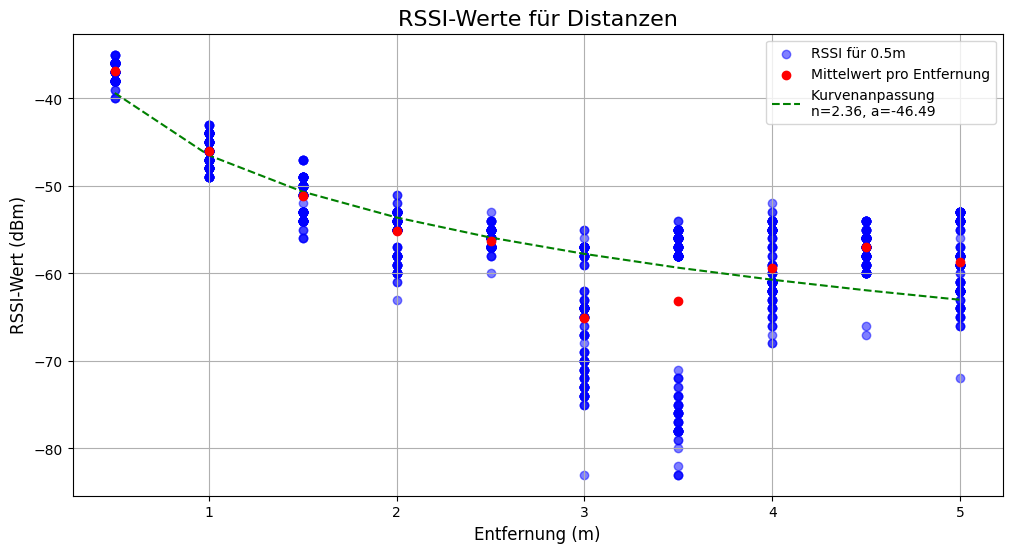

In [43]:
# Excel-Datei einlesen
df = pd.read_excel(file_name, header=1)  # Die zweite Zeile enthält die Spaltenüberschriften
distances = pd.read_excel(file_name, header=None).iloc[0].dropna().unique()  # Die erste Zeile enthält die Distanzen

num_filters = 5  # Anzahl der Filter (RAW, FLUCT, KALMAN, MEDIAN, MAX)
mean_rssi_per_distance = {}

# Distance Path-Loss Model definieren
def rssi_model(distance, n, a):
    return -10 * n * np.log10(distance) + a

# Graphen erstellen
plt.figure(figsize=(12, 6))

for i, dist in enumerate(distances):
    # Spalten für die aktuelle Distanz extrahieren
    start_col = i * (num_filters + 1)  # Startspalte für diese Distanz
    cols = df.columns[start_col : start_col + (num_filters + 1)]  # Zeitsäule + Filterspalten

    # Sub-DataFrame erstellen
    dist_df = df[cols].rename(columns={
        cols[0]: 'TimeStep',
        cols[1]: 'RAW',
        cols[2]: 'FLUCT',
        cols[3]: 'KALMAN',
        cols[4]: 'MEDIAN',
        cols[5]: 'MAX'
    })

    # NaN-Werte interpolieren
    dist_df = dist_df.interpolate()

    # Mittelwert der RSSI-Werte für jede Entfernung berechnen
    mean_rssi_per_distance[dist] = dist_df['RAW'].mean()

    # Einzelne RSSI-Werte für diese Distanz darstellen
    plt.scatter([dist] * len(dist_df), dist_df['RAW'], color='blue', alpha=0.5, label=f'RSSI für {dist}m' if i == 0 else "")

# Curve-Fit durchführen
popt, pcov = curve_fit(rssi_model, list(mean_rssi_per_distance.keys()), list(mean_rssi_per_distance.values()))

# Optimierte Parameter
n, a = popt
print(f"Optimierte Parameter: n = {n:.2f}, a = {a:.2f}")

# Fit-Daten berechnen
fitted_rssi = rssi_model(np.array(list(mean_rssi_per_distance.keys())), n, a)

# Mittelwert als Punkte für jede Entfernung zeichnen
plt.scatter(list(mean_rssi_per_distance.keys()), list(mean_rssi_per_distance.values()),
            color='red', label='Mittelwert pro Entfernung', zorder=5)

# Angepasste Kurve hinzufügen
plt.plot(list(mean_rssi_per_distance.keys()), fitted_rssi,
         color='green', linestyle='--',
         label=f'Kurvenanpassung \nn={n:.2f}, a={a:.2f}')

# Titel und Achsenbeschriftungen hinzufügen
plt.title("RSSI-Werte für Distanzen", fontsize=16)
plt.xlabel("Entfernung (m)", fontsize=12)
plt.ylabel("RSSI-Wert (dBm)", fontsize=12)

# Legende hinzufügen
plt.legend()

# Raster aktivieren
plt.grid(True)

# Plot anzeigen
plt.show()

# 2.1 RSSI mit Hard Fluctuation Filter für mehrere Distanzen
*mit Distance Path Loss n, m Parameter kalibrierung*

Optimierte Parameter: n = 2.25, a = -46.29


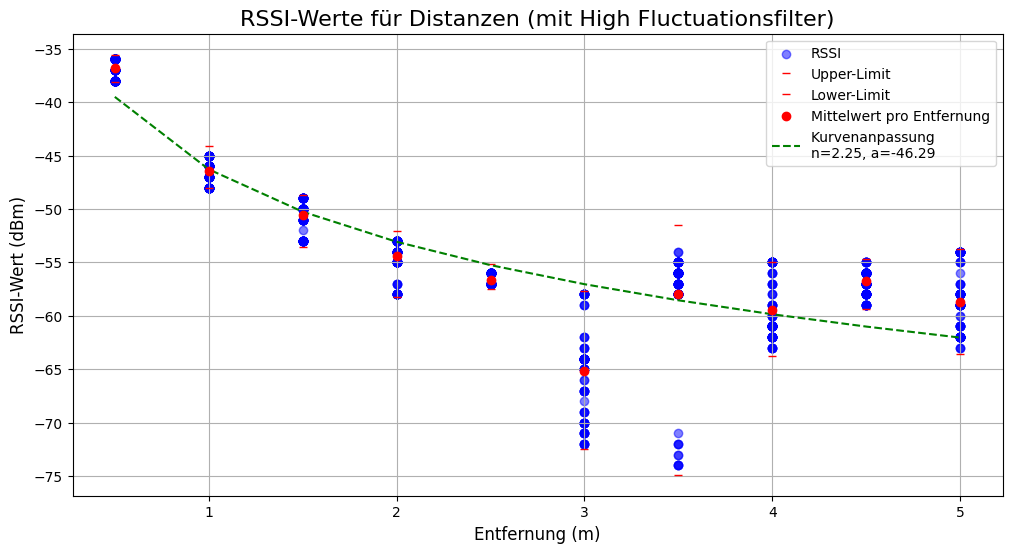

In [54]:
# Excel-Datei einlesen
df = pd.read_excel(file_name, header=1)  # Die zweite Zeile enthält die Spaltenüberschriften
distances = pd.read_excel(file_name, header=None).iloc[0].dropna().unique()  # Die erste Zeile enthält die Distanzen

num_filters = 5  # Anzahl der Filter (RAW, FLUCT, KALMAN, MEDIAN, MAX)
mean_rssi_per_distance = {}
std_rssi_per_distance = {}

# Distance Path-Loss Model definieren
def rssi_model(distance, n, a):
    return -10 * n * np.log10(distance) + a

# Graphen erstellen
plt.figure(figsize=(12, 6))

for i, dist in enumerate(distances):
    # Spalten für die aktuelle Distanz extrahieren
    start_col = i * (num_filters + 1)  # Startspalte für diese Distanz
    cols = df.columns[start_col : start_col + (num_filters + 1)]  # Zeitsäule + Filterspalten

    # Sub-DataFrame erstellen
    dist_df = df[cols].rename(columns={
        cols[0]: 'TimeStep',
        cols[1]: 'RAW',
        cols[2]: 'FLUCT',
        cols[3]: 'KALMAN',
        cols[4]: 'MEDIAN',
        cols[5]: 'MAX'
    })

    # NaN-Werte interpolieren
    dist_df = dist_df.interpolate()

    # Mittelwert und Standardabweichung berechnen
    mean_rssi_per_distance[dist] = dist_df['RAW'].mean()
    std_rssi_per_distance[dist] = dist_df['RAW'].std()

    # Upper Limit und Lower Limit bestimmen
    upper_limit = mean_rssi_per_distance[dist] + (1.2 * std_rssi_per_distance[dist])
    lower_limit = mean_rssi_per_distance[dist] - (1.2 * std_rssi_per_distance[dist])

    # Daten Filtern
    dist_df['Filtered'] = dist_df['RAW'].where((dist_df['RAW'] <= upper_limit) & (dist_df['RAW'] >= lower_limit))

    # Mittelwert neu bestimmen
    mean_rssi_per_distance[dist] = dist_df['Filtered'].mean()

    # Einzelne RSSI-Werte für diese Distanz darstellen
    plt.scatter([dist] * len(dist_df), dist_df['Filtered'], color='blue', alpha=0.5, label=f'RSSI' if i == 0 else "")

    # Upper- und Lowerlimit zeichnen
    plt.plot(dist, upper_limit, color='red', linestyle='None', marker='_', label=f'Upper-Limit' if i == 0 else "")
    plt.plot(dist, lower_limit, color='red', linestyle='None', marker='_', label=f'Lower-Limit' if i == 0 else "")

# Curve-Fit durchführen
popt, pcov = curve_fit(rssi_model, list(mean_rssi_per_distance.keys()), list(mean_rssi_per_distance.values()))

# Optimierte Parameter
n, a = popt
print(f"Optimierte Parameter: n = {n:.2f}, a = {a:.2f}")

# Fit-Daten berechnen
fitted_rssi = rssi_model(np.array(list(mean_rssi_per_distance.keys())), n, a)

# Mittelwert als Punkte für jede Entfernung zeichnen
plt.scatter(list(mean_rssi_per_distance.keys()), list(mean_rssi_per_distance.values()),
            color='red', label='Mittelwert pro Entfernung', zorder=5)

# Angepasste Kurve hinzufügen
plt.plot(list(mean_rssi_per_distance.keys()), fitted_rssi,
         color='green', linestyle='--',
         label=f'Kurvenanpassung \nn={n:.2f}, a={a:.2f}')

# Titel und Achsenbeschriftungen hinzufügen
plt.title("RSSI-Werte für Distanzen (mit High Fluctuationsfilter)", fontsize=16)
plt.xlabel("Entfernung (m)", fontsize=12)
plt.ylabel("RSSI-Wert (dBm)", fontsize=12)

# Legende hinzufügen
plt.legend()

# Raster aktivieren
plt.grid(True)

# Plot anzeigen
plt.show()

# 3. Vergleich unterschiedliche RSSI Filter

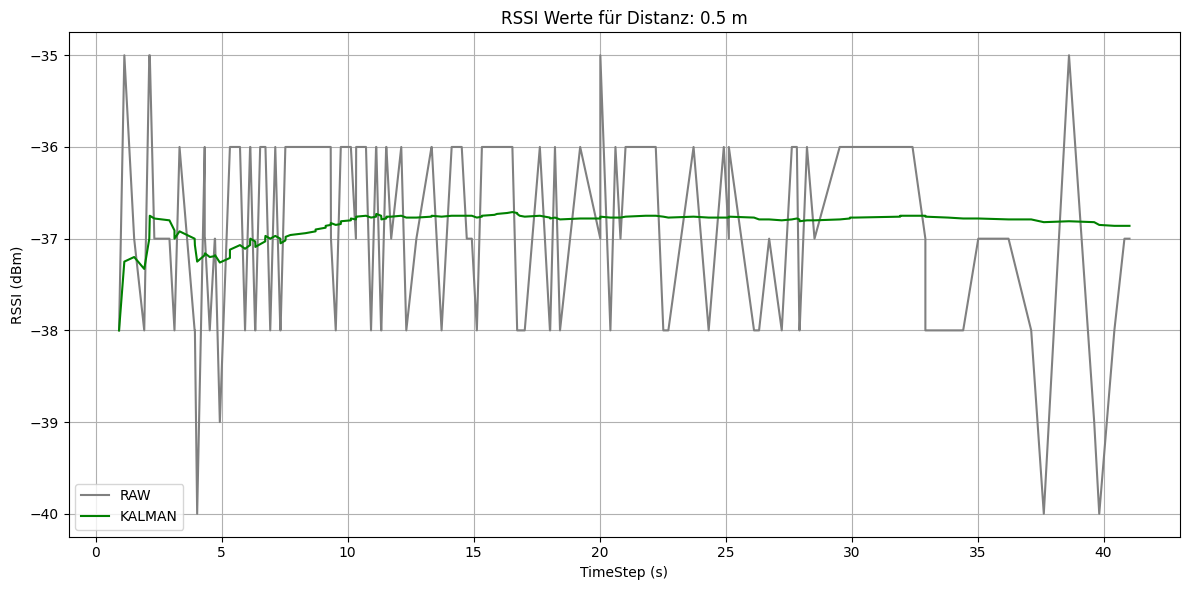

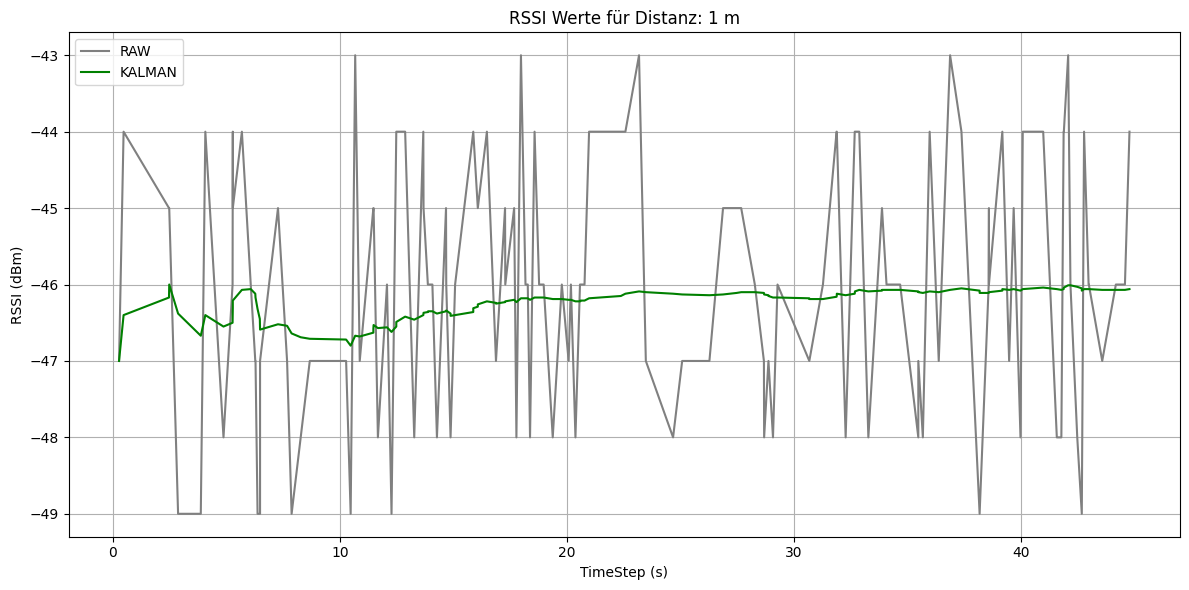

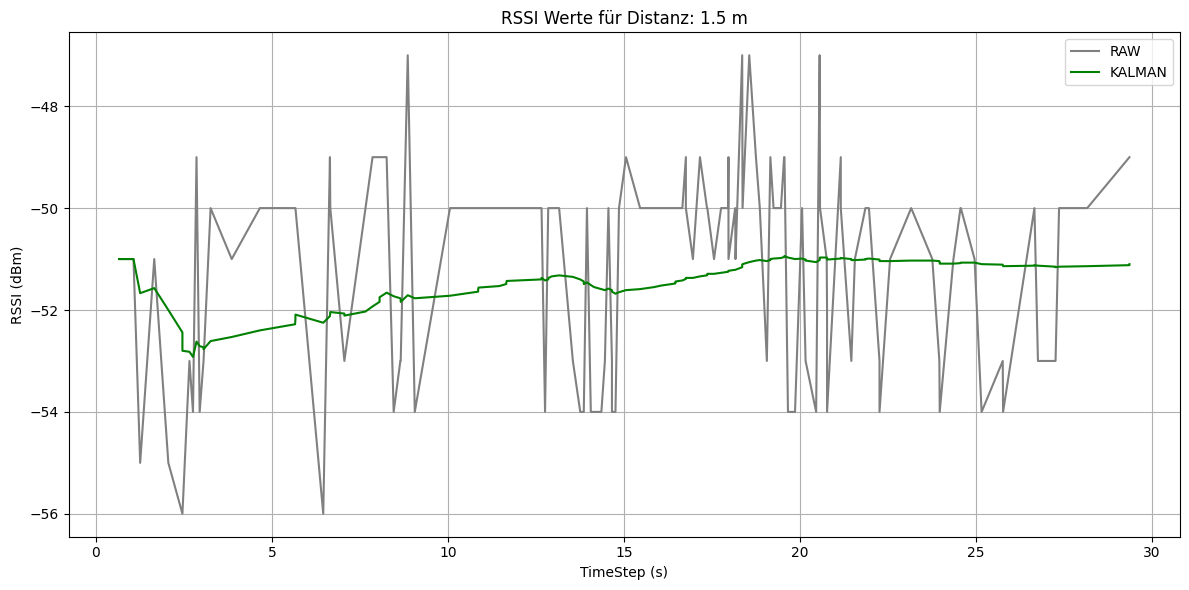

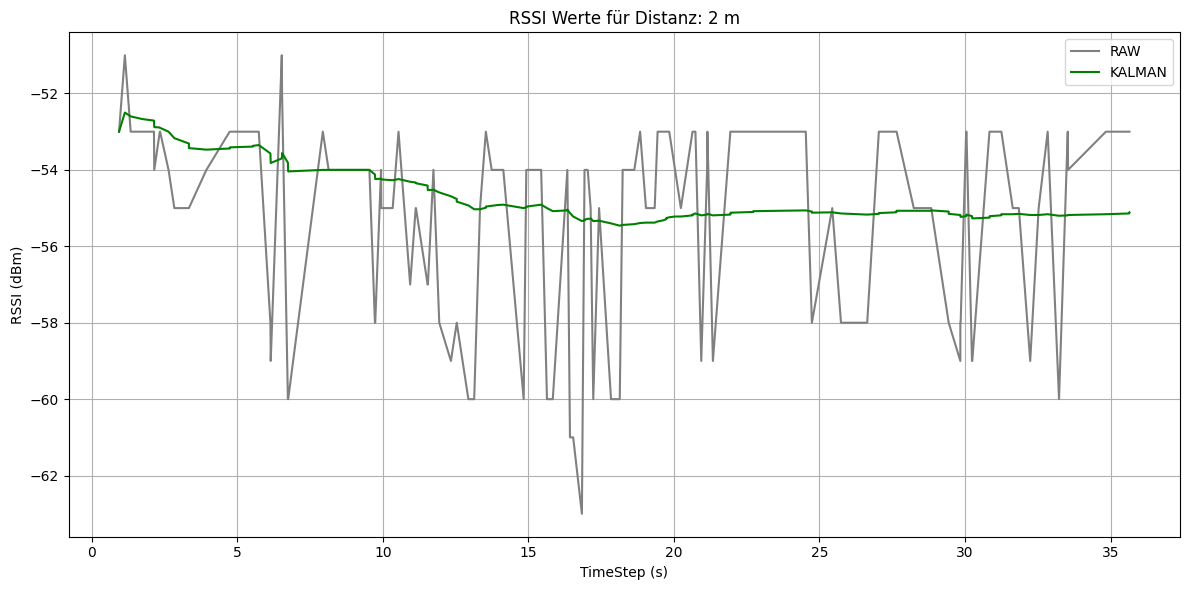

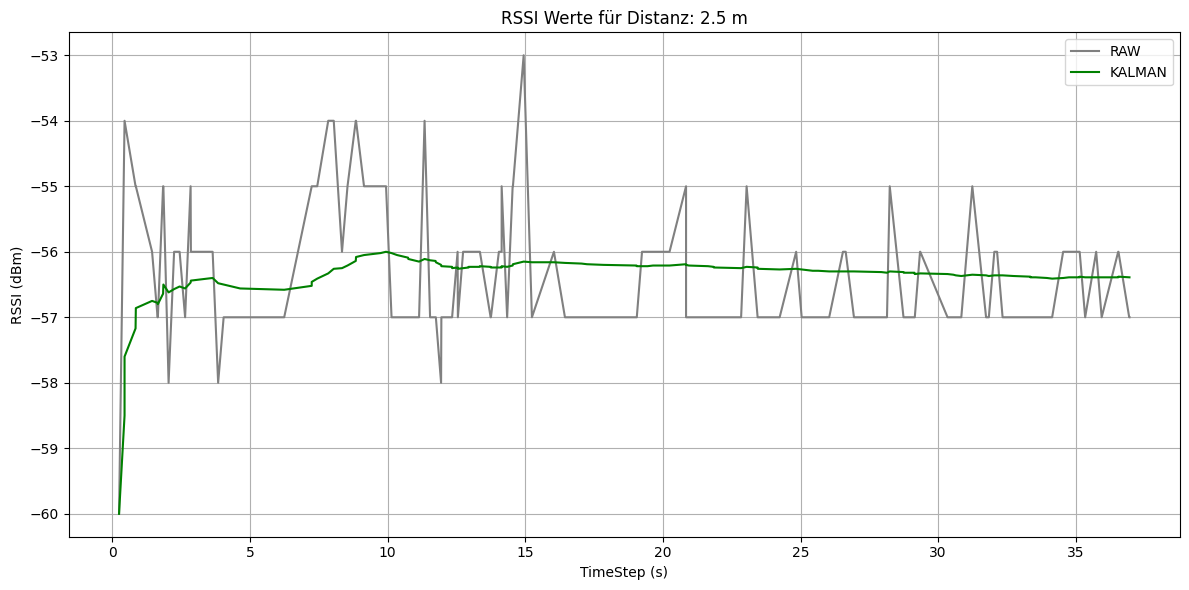

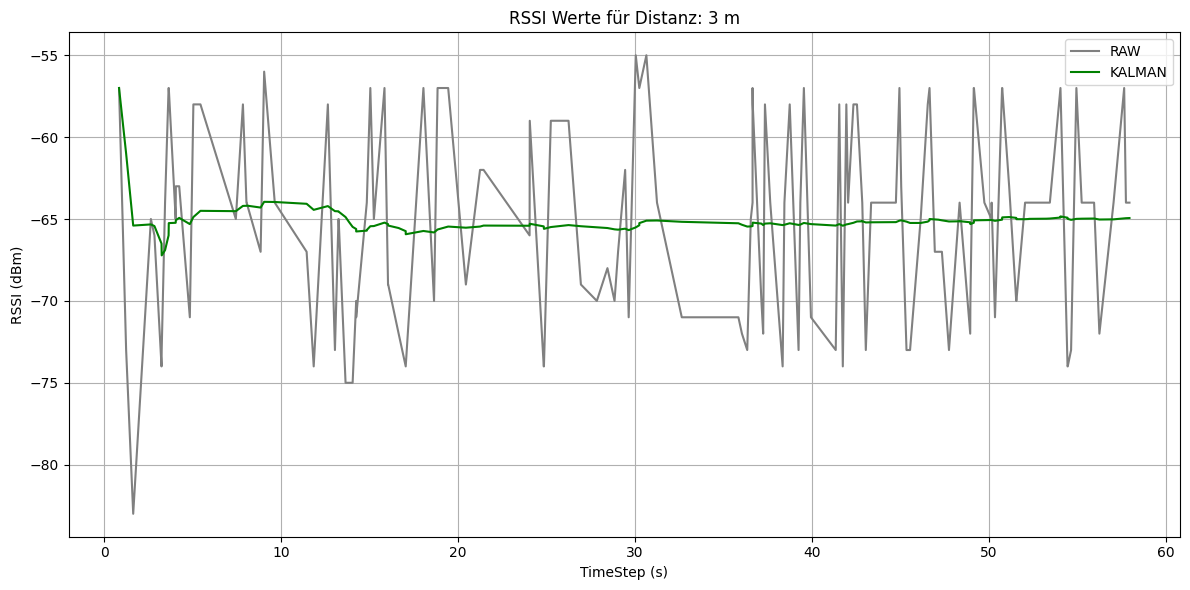

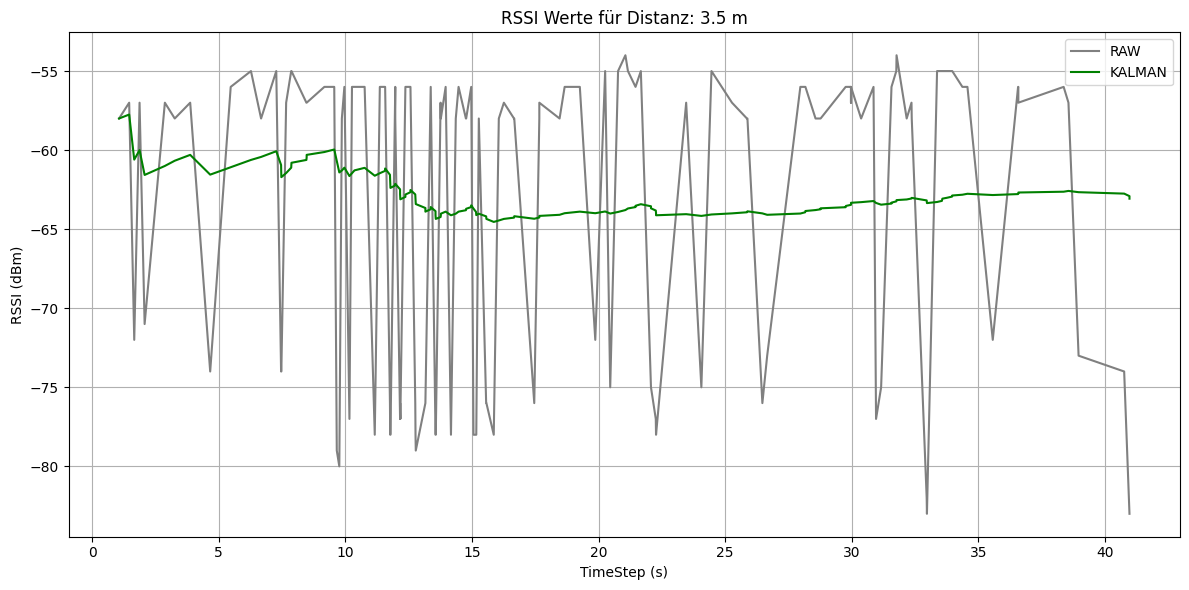

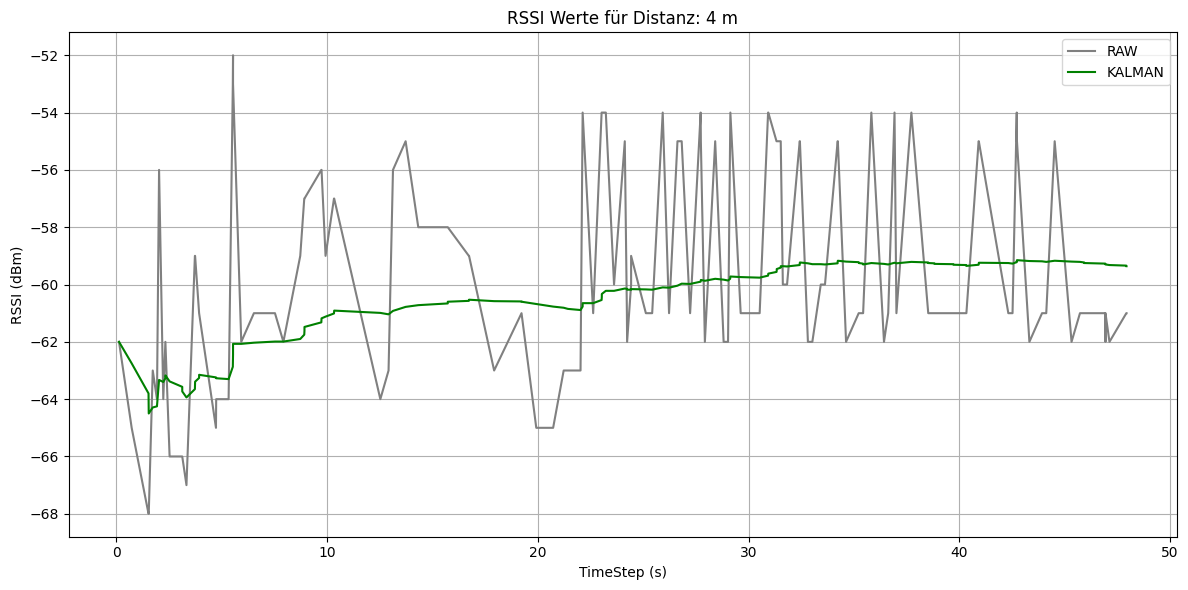

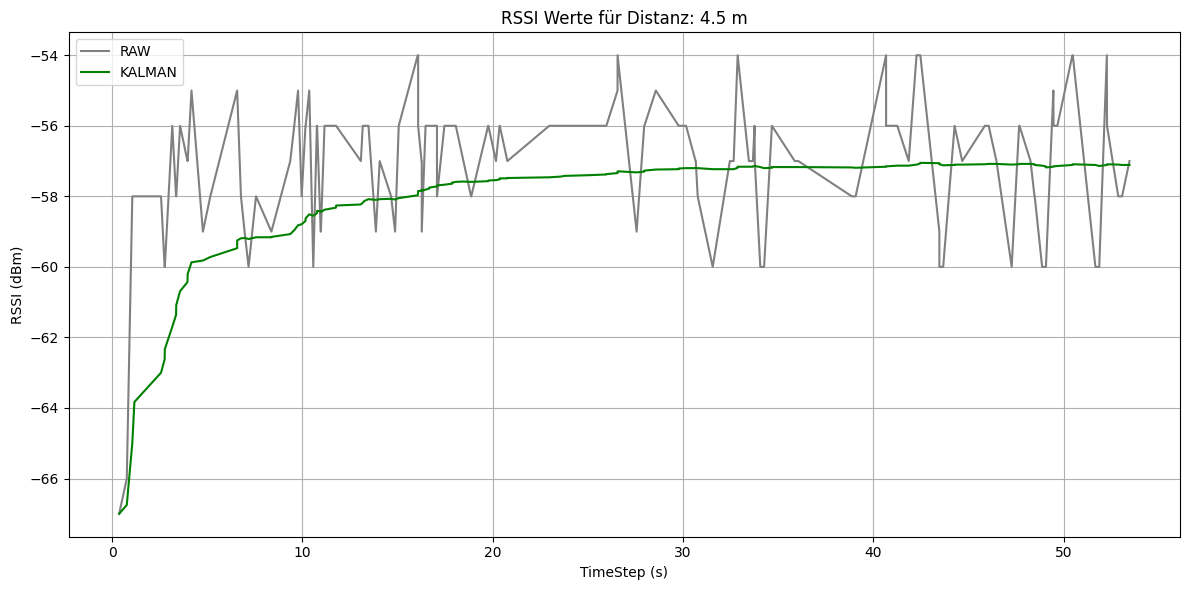

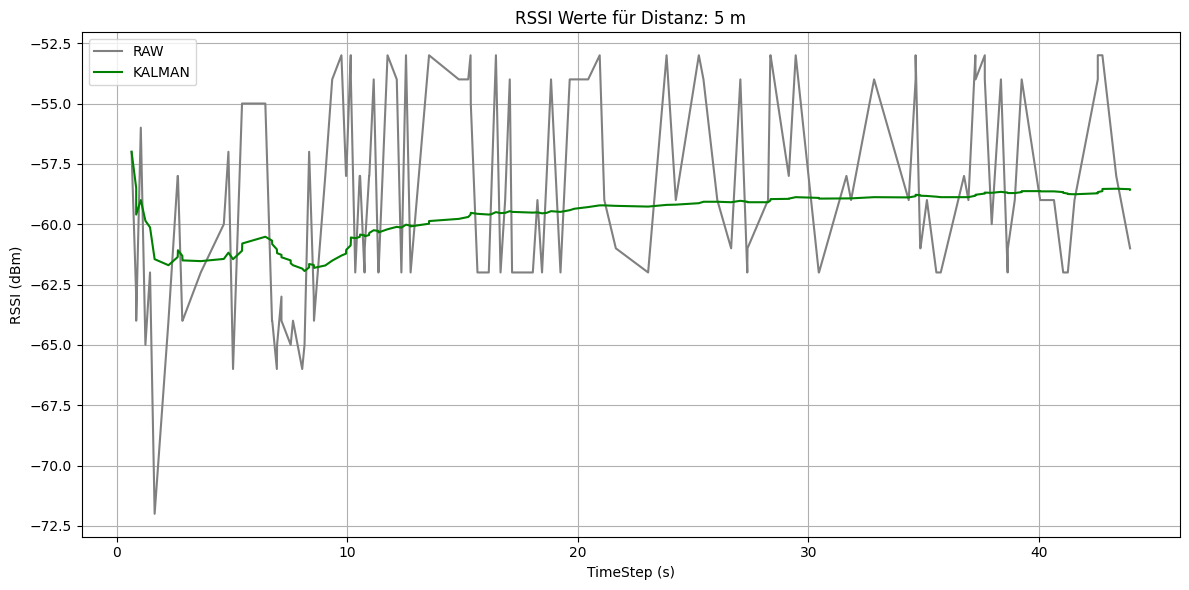

In [55]:
# Filter wählen:
display_filter = ['RAW','KALMAN'] # ['RAW','FLUCT','KALMAN','MEDIAN','MAX']

# Excel-Datei einlesen
df = pd.read_excel(file_name, header=1)  # Die zweite Zeile enthält die Spaltenüberschriften
distances = pd.read_excel(file_name, header=None).iloc[0].dropna().unique()  # Die erste Zeile enthält die Distanzen

num_filters = 5  # Anzahl der Filter (RAW, FLUCT, KALMAN, MEDIAN, MAX)

for i, dist in enumerate(distances):
    # Spalten für die aktuelle Distanz extrahieren
    start_col = i * (num_filters + 1)  # Startspalte für diese Distanz
    cols = df.columns[start_col : start_col + (num_filters + 1)]  # Zeitsäule + Filterspalten

    # Sub-DataFrame erstellen
    dist_df = df[cols].rename(columns={
        cols[0]: 'TimeStep',
        cols[1]: 'RAW',
        cols[2]: 'FLUCT',
        cols[3]: 'KALMAN',
        cols[4]: 'MEDIAN',
        cols[5]: 'MAX'
    })

    # NaN-Werte interpolieren
    dist_df = dist_df.interpolate()

    # Graphen erstellen
    plt.figure(figsize=(12, 6))

    if 'RAW' in display_filter:
        plt.plot(dist_df['TimeStep'], dist_df['RAW'], label='RAW', color='gray', linestyle='-')
    if 'FLUCT' in display_filter:
        plt.plot(dist_df['TimeStep'], dist_df['FLUCT'], label='FLUCT', color='blue', linestyle='-')
    if 'KALMAN' in display_filter:
        plt.plot(dist_df['TimeStep'], dist_df['KALMAN'], label='KALMAN', color='green', linestyle='-')
    if 'MEDIAN' in display_filter:
        plt.plot(dist_df['TimeStep'], dist_df['MEDIAN'], label='MEDIAN', color='red', linestyle='-')
    if 'MAX' in display_filter:
        plt.plot(dist_df['TimeStep'], dist_df['MAX'], label='MAX', color='orange', linestyle='-.')

    # Achsenbeschriftungen und Titel
    plt.ylabel('RSSI (dBm)')
    plt.xlabel('TimeStep (s)')
    plt.title(f'RSSI Werte für Distanz: {dist} m')
    plt.legend()
    plt.grid()
    plt.tight_layout()

    # Diagramm anzeigen
    plt.show()

# 3.1 Berechnete Distanzen für unterschiedliche Filter

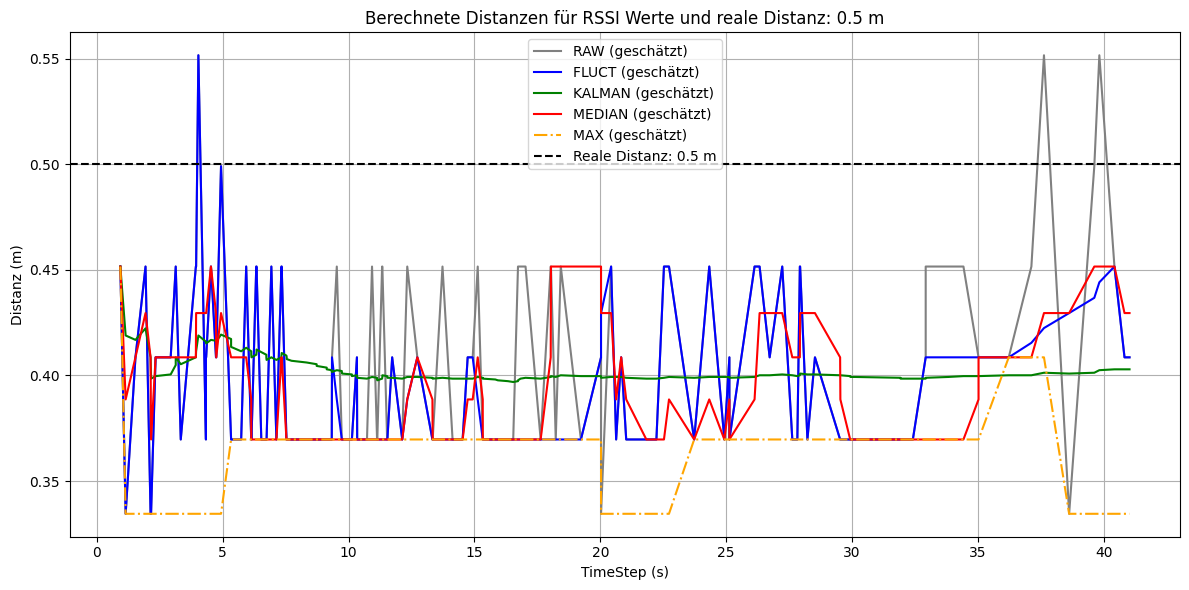

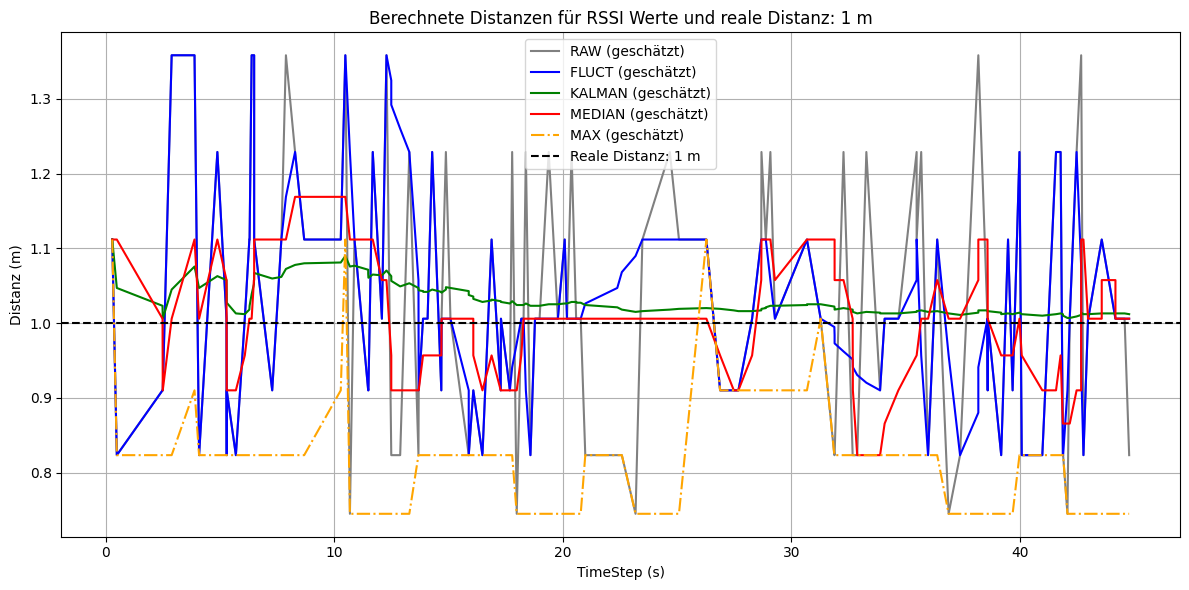

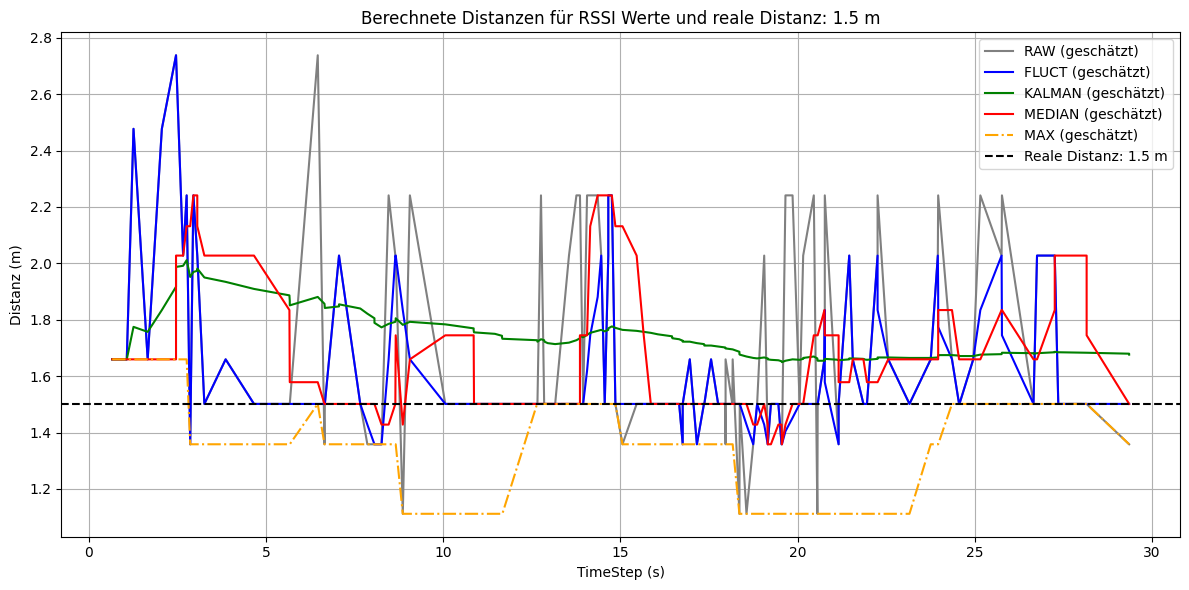

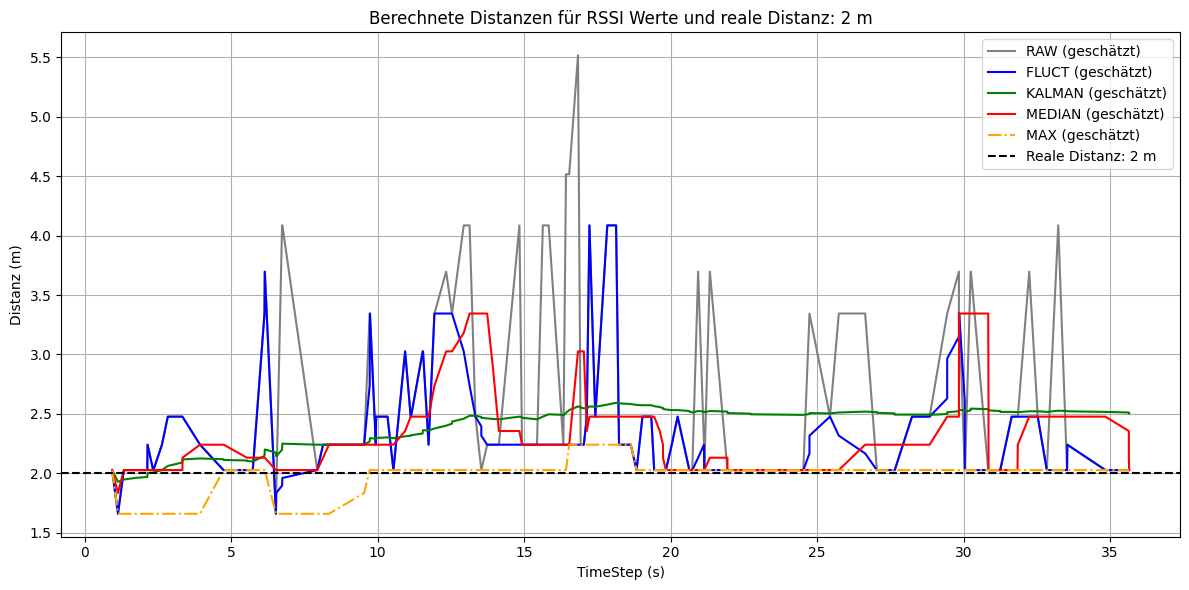

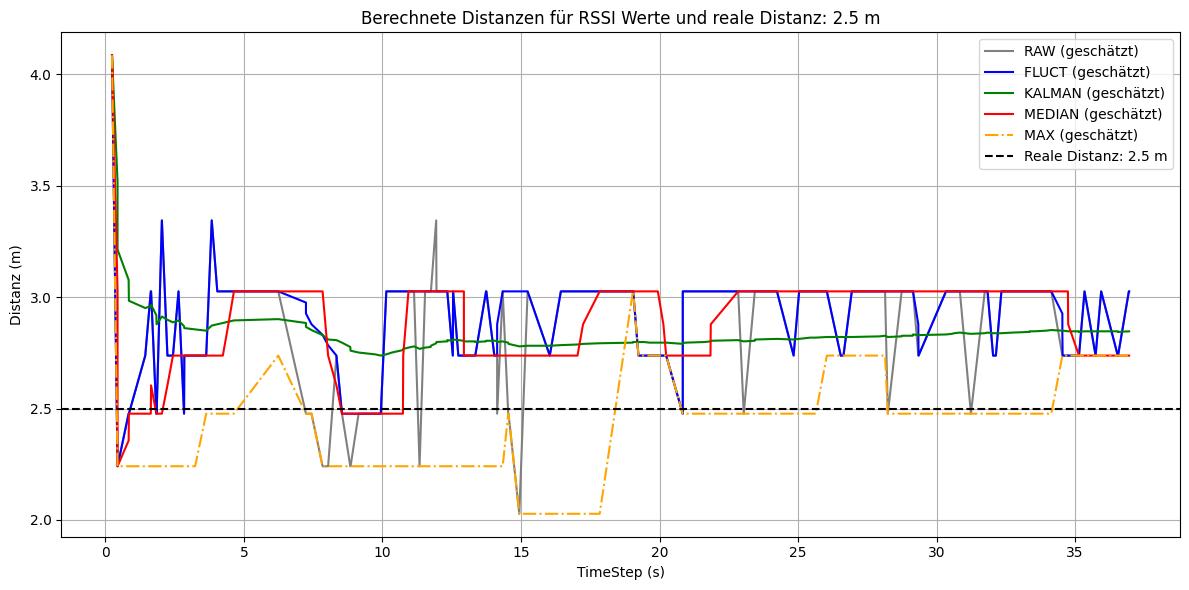

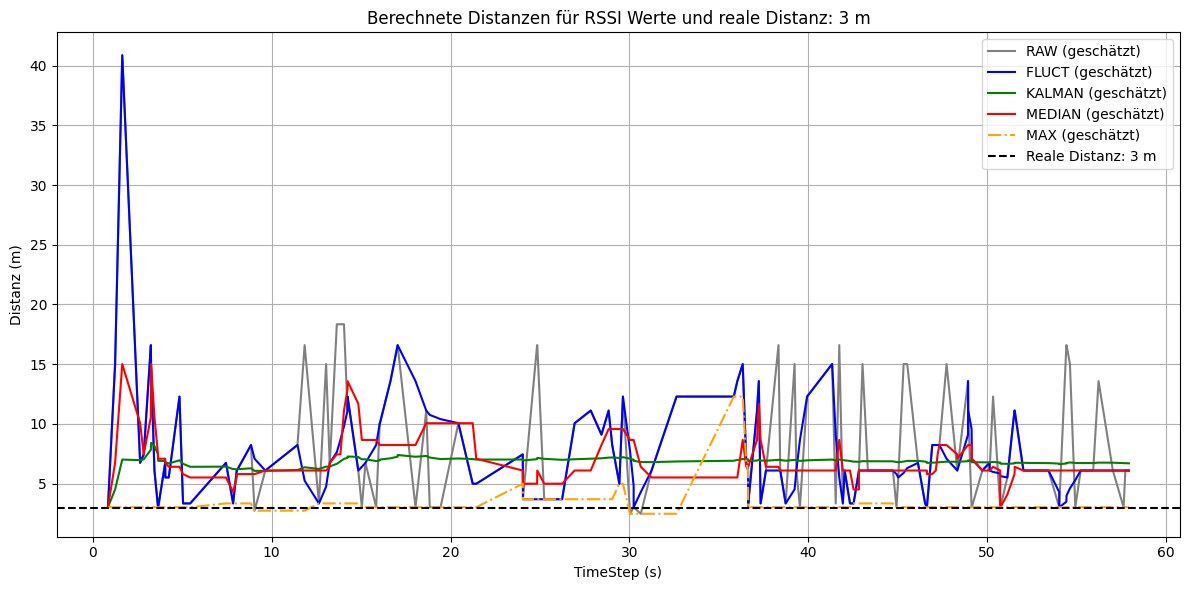

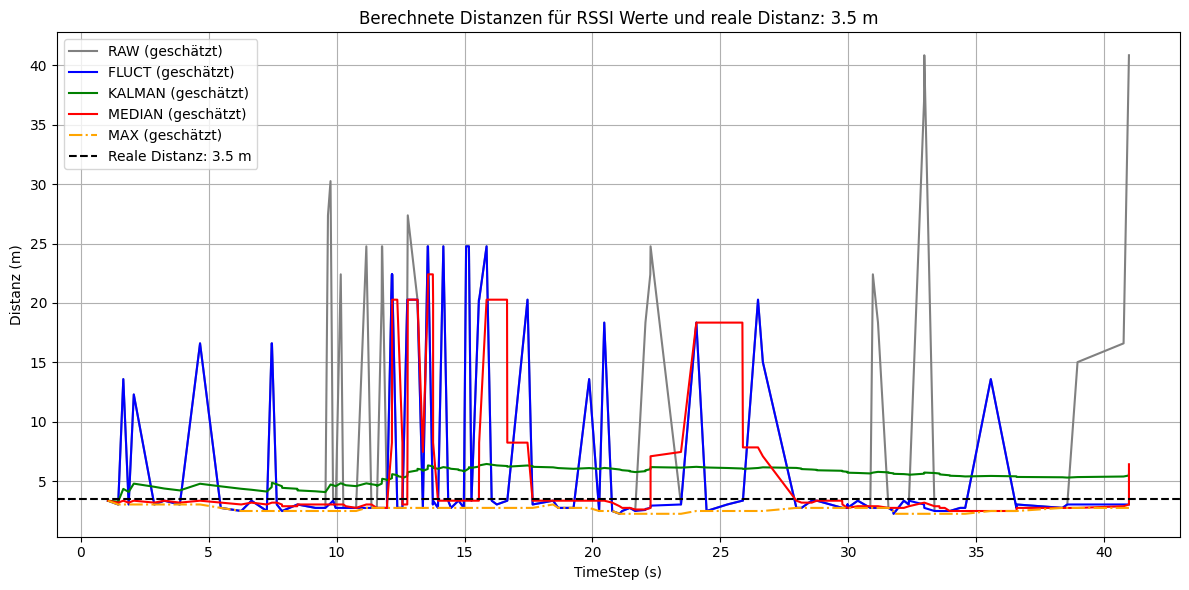

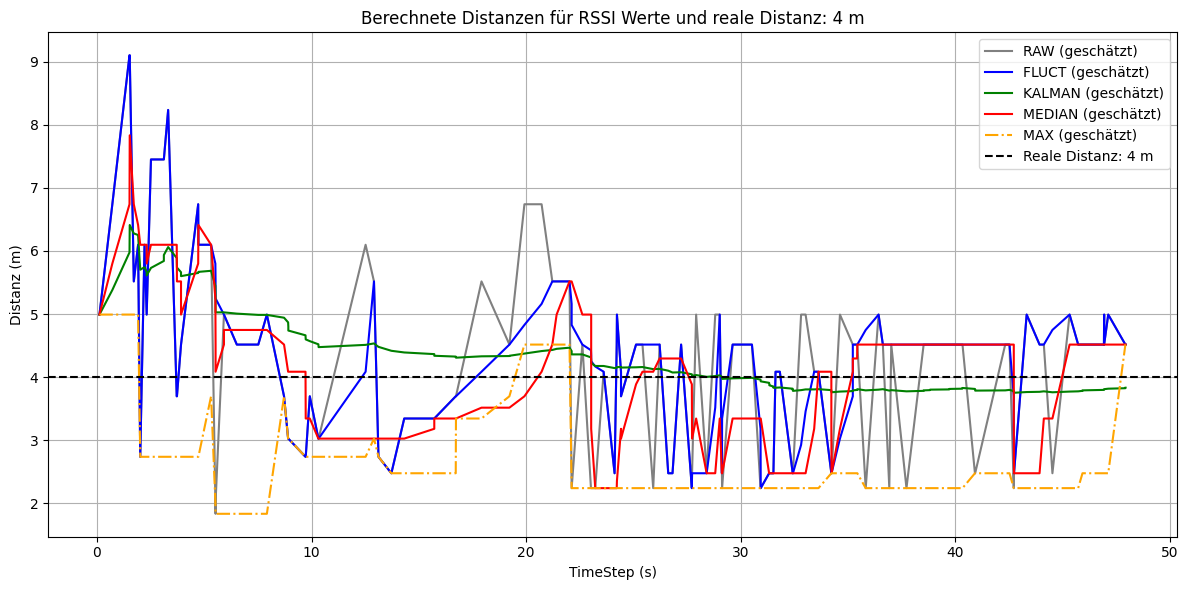

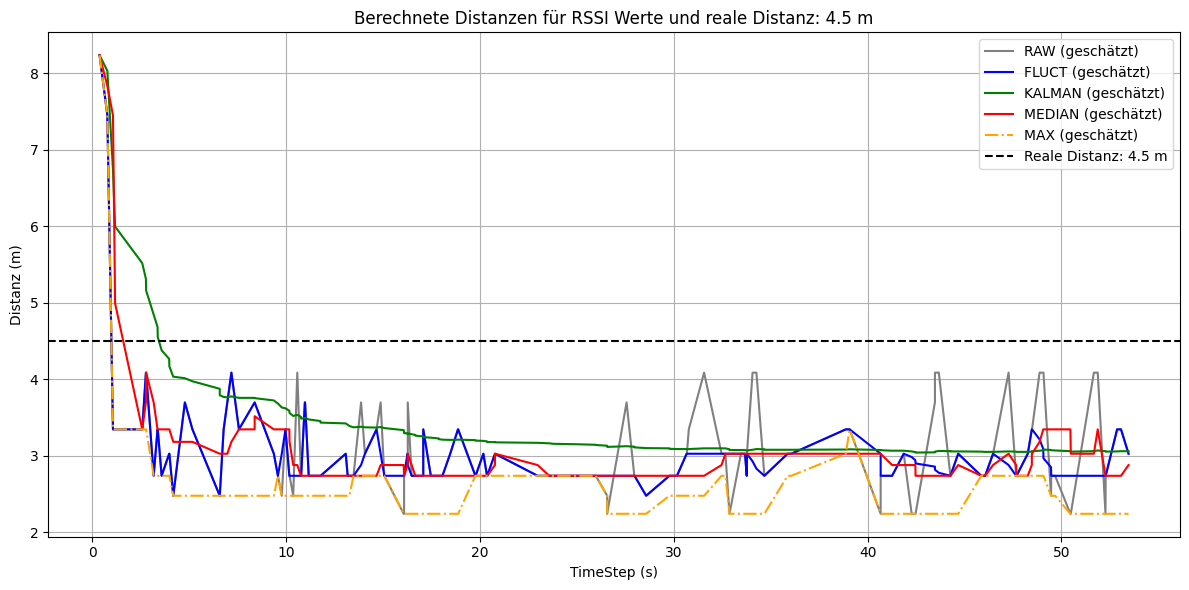

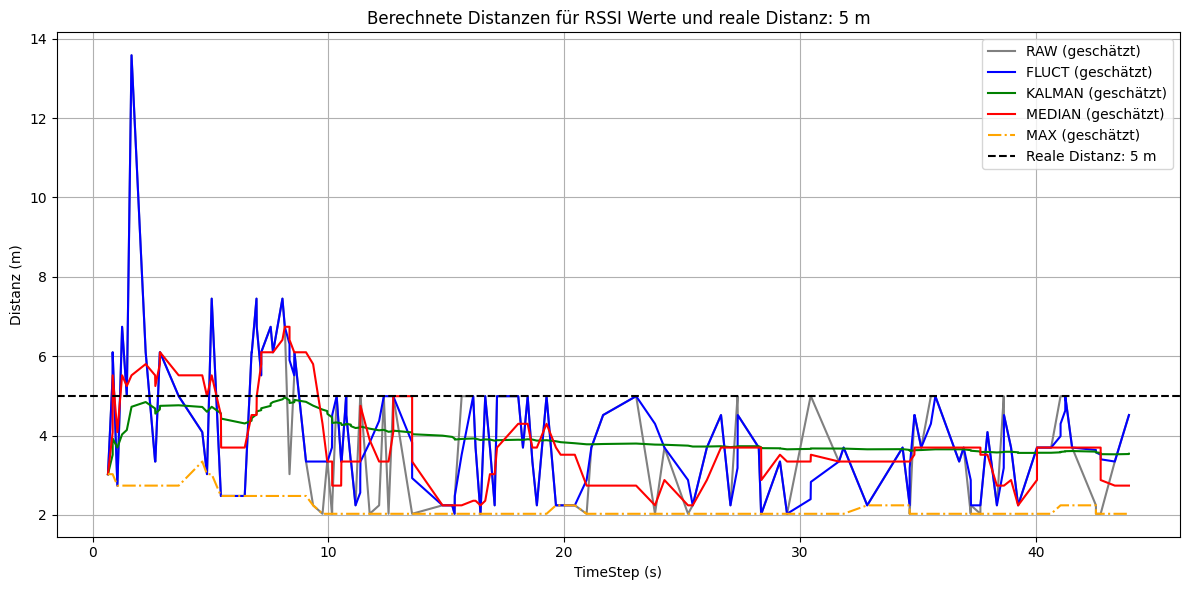

In [58]:
# Logarithmische Path Loss Funktion zur Berechnung der Distanz
def logarithmic_distance_path_loss(rssi, rssi_one_meter, disturbance_level):
    n = round(disturbance_level, 2)
    a = round(rssi_one_meter, 2)

    # Berechnung der Entfernung
    return 10**((a - rssi) / (10 * n))

# Parameter
rssi_one_meter = -45.94  # RSSI-Wert bei 1 Meter (dBm), anpassen
disturbance_level = 2.30  # Störungseffekt (Wert n, anpassen)

# Anzahl der Filter (RAW, FLUCT, KALMAN, MEDIAN, MAX)
num_filters = 5

# Variablen, um die berechneten Distanzen zu speichern
distances_estimated_all = {}
real_distances = []

for i, dist in enumerate(distances):
    real_distances.append(dist)

    # Spalten für die aktuelle Distanz extrahieren
    start_col = i * (num_filters + 1)  # Startspalte für diese Distanz
    cols = df.columns[start_col : start_col + (num_filters + 1)]  # Zeitsäule + Filterspalten

    # Sub-DataFrame erstellen
    dist_df = df[cols].rename(columns={
        cols[0]: 'TimeStep',
        cols[1]: 'RAW',
        cols[2]: 'FLUCT',
        cols[3]: 'KALMAN',
        cols[4]: 'MEDIAN',
        cols[5]: 'MAX'
    })

    # NaN-Werte interpolieren
    dist_df = dist_df.interpolate()

    # Berechnete Distanzen aus RSSI-Werten für jeden Filter
    distances_estimated = {
        'RAW': [],
        'FLUCT': [],
        'KALMAN': [],
        'MEDIAN': [],
        'MAX': []
    }

    # Berechnung der Distanzen für jedes Filter
    for filter_name in distances_estimated.keys():
        for rssi in dist_df[filter_name]:
            distance_est = logarithmic_distance_path_loss(rssi, rssi_one_meter, disturbance_level)
            distances_estimated[filter_name].append(distance_est)

    # Speichern der berechneten Distanzen für diese Distanz
    distances_estimated_all[dist] = distances_estimated

    # Plot für die aktuellen Distanzen erstellen
    plt.figure(figsize=(12, 6))

    # Plot der geschätzten Distanzen basierend auf den verschiedenen Filtern
    plt.plot(dist_df['TimeStep'], distances_estimated['RAW'], label='RAW (geschätzt)', color='gray', linestyle='-')
    plt.plot(dist_df['TimeStep'], distances_estimated['FLUCT'], label='FLUCT (geschätzt)', color='blue', linestyle='-')
    plt.plot(dist_df['TimeStep'], distances_estimated['KALMAN'], label='KALMAN (geschätzt)', color='green', linestyle='-')
    plt.plot(dist_df['TimeStep'], distances_estimated['MEDIAN'], label='MEDIAN (geschätzt)', color='red', linestyle='-')
    plt.plot(dist_df['TimeStep'], distances_estimated['MAX'], label='MAX (geschätzt)', color='orange', linestyle='-.')

    # Realen Distanz als Referenz einzeichnen
    plt.axhline(y=dist, color='black', linestyle='--', label=f'Reale Distanz: {dist} m')

    # Achsenbeschriftungen und Titel
    plt.ylabel('Distanz (m)')
    plt.xlabel('TimeStep (s)')
    plt.title(f'Berechnete Distanzen für RSSI Werte und reale Distanz: {dist} m')
    plt.legend()
    plt.grid()
    plt.tight_layout()

    # Diagramm anzeigen
    plt.show()


# 3.2 Fehlerplot als kumulative Verteilungsfunktion (CDF)

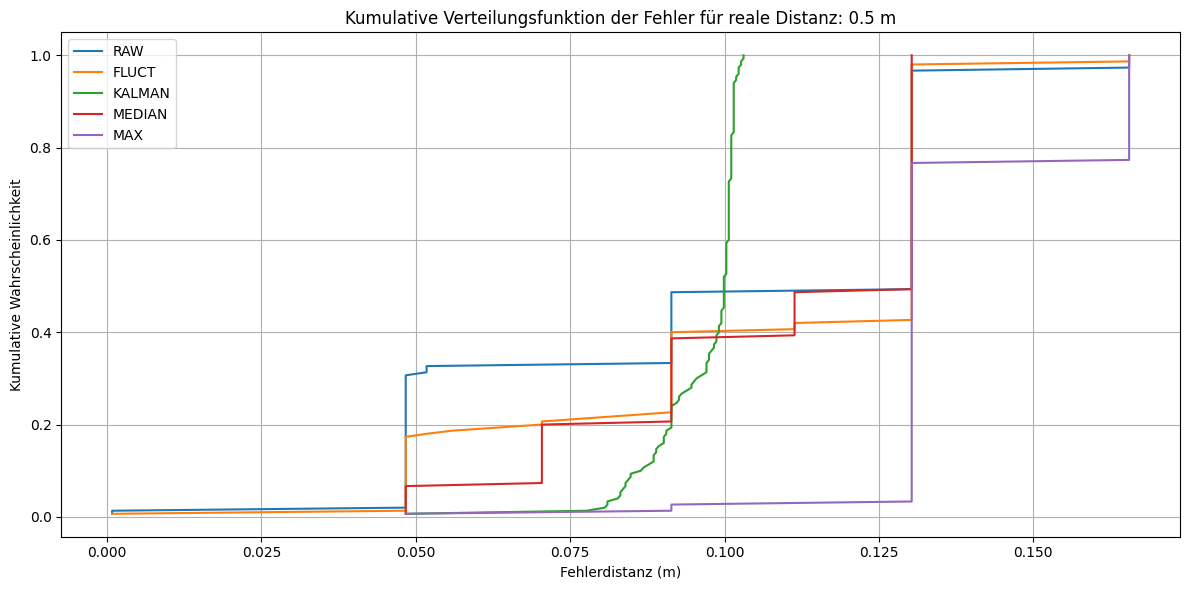

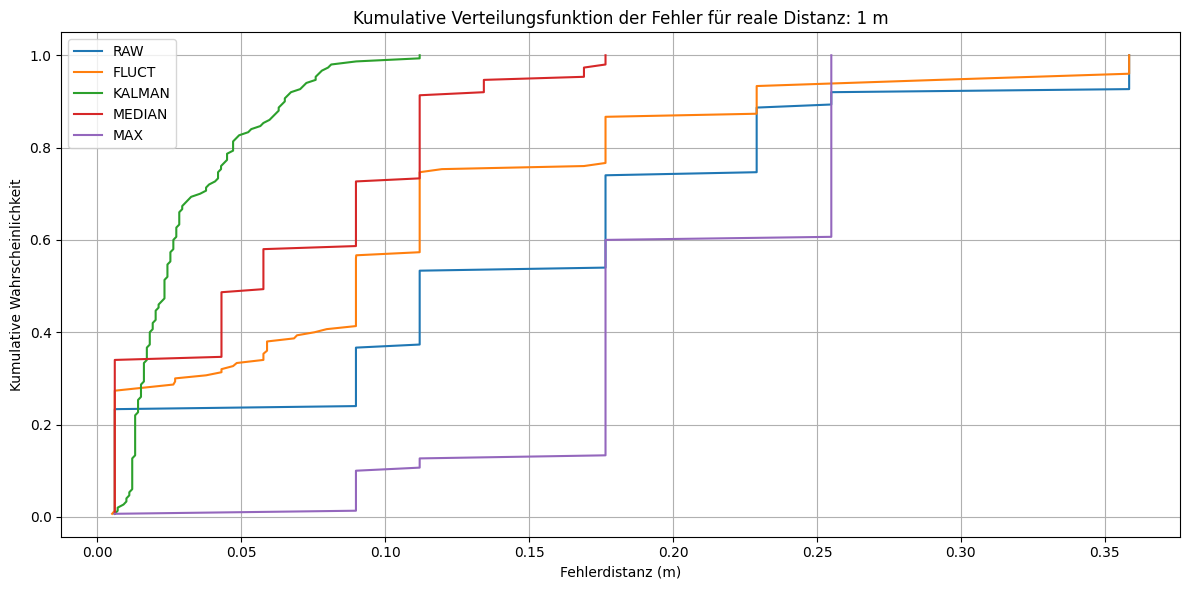

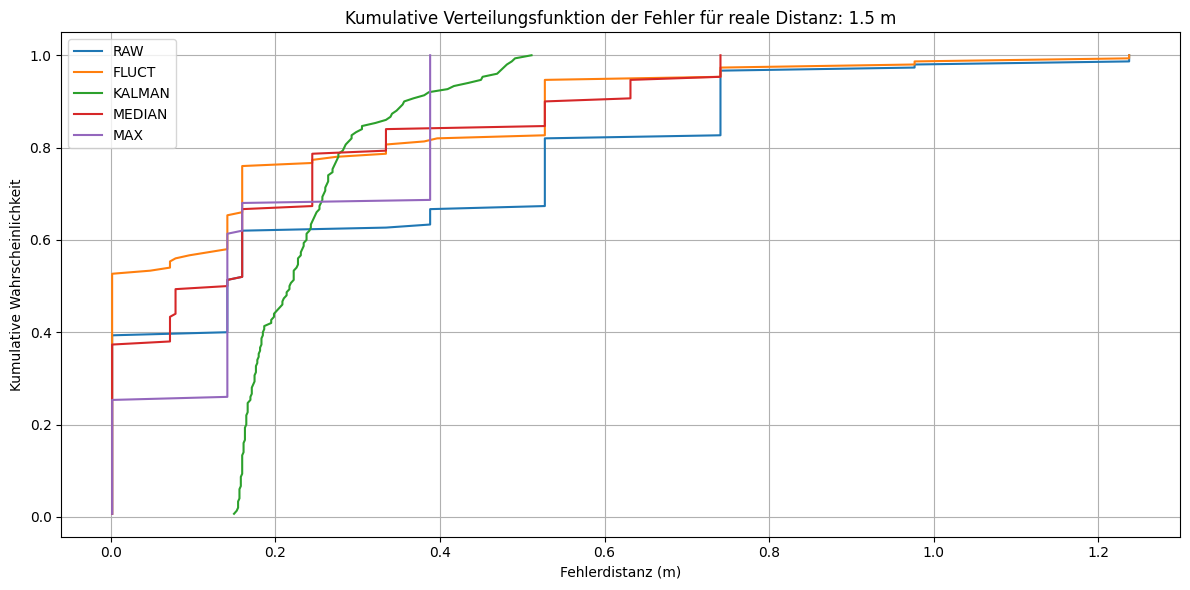

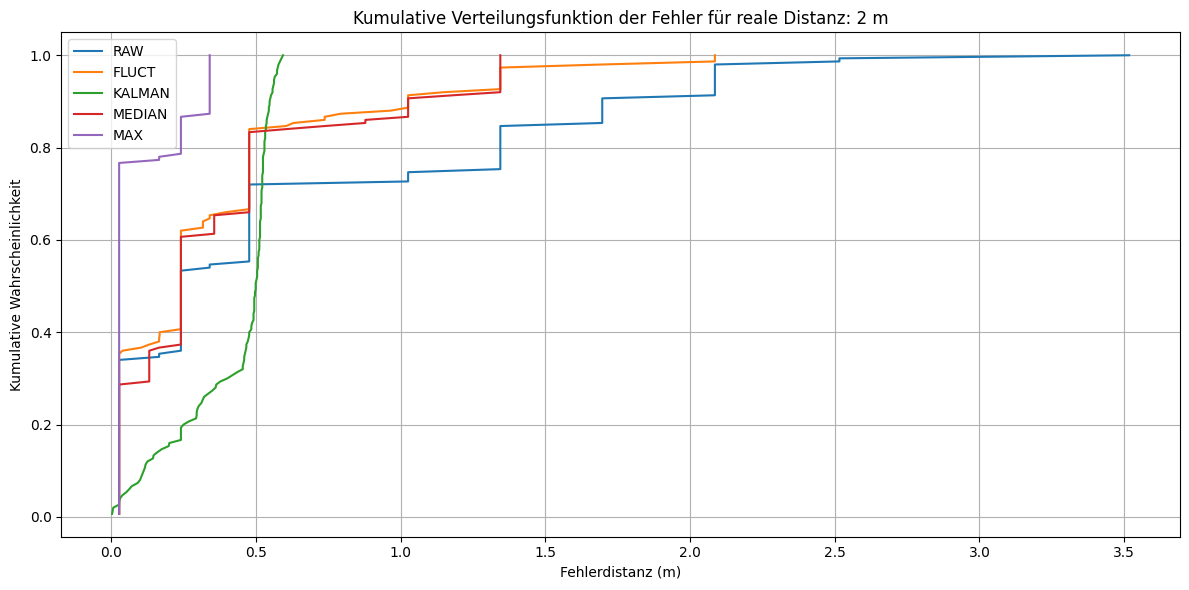

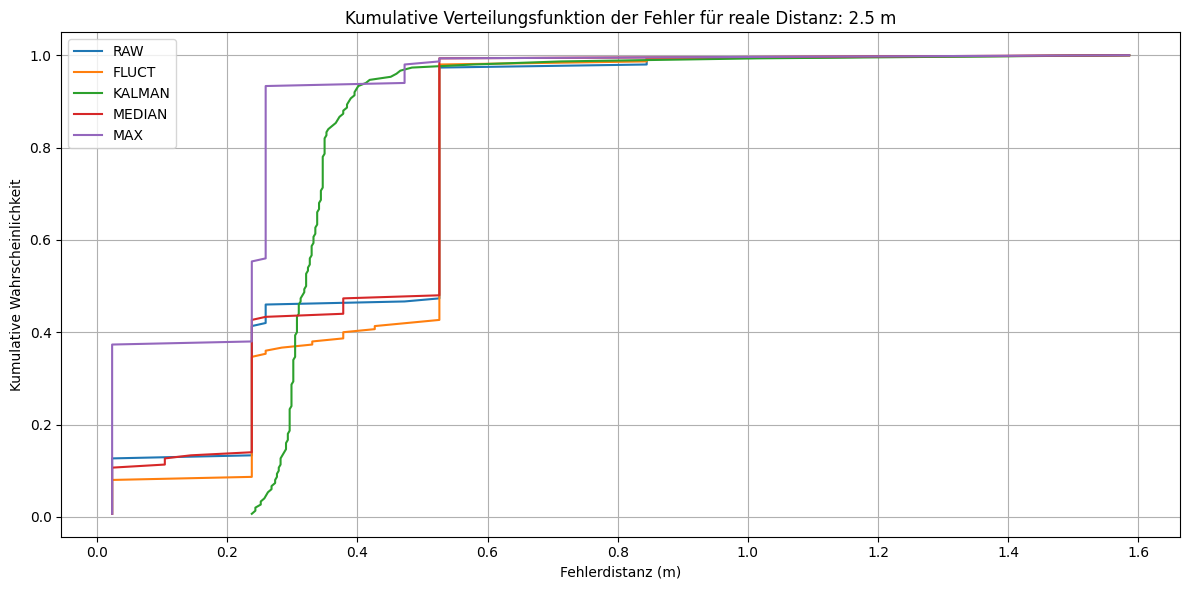

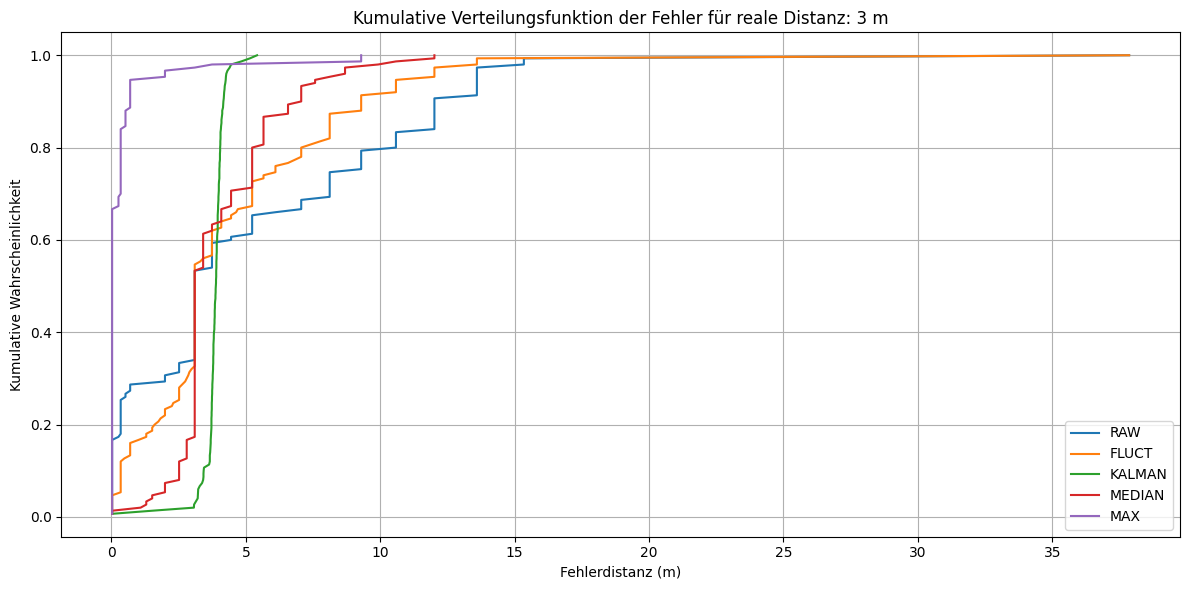

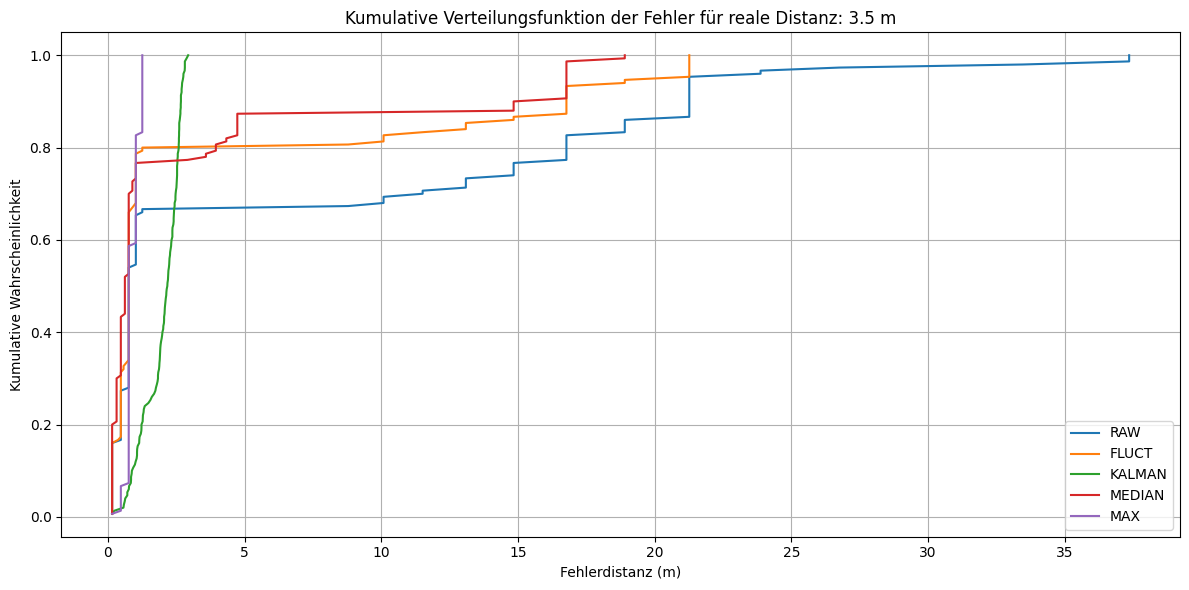

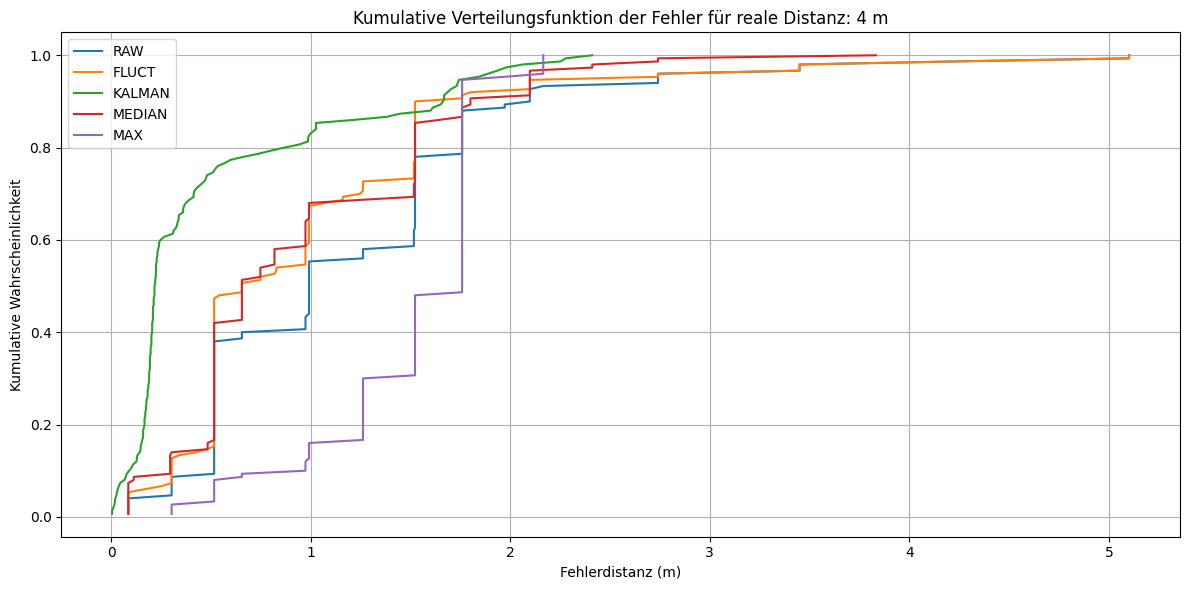

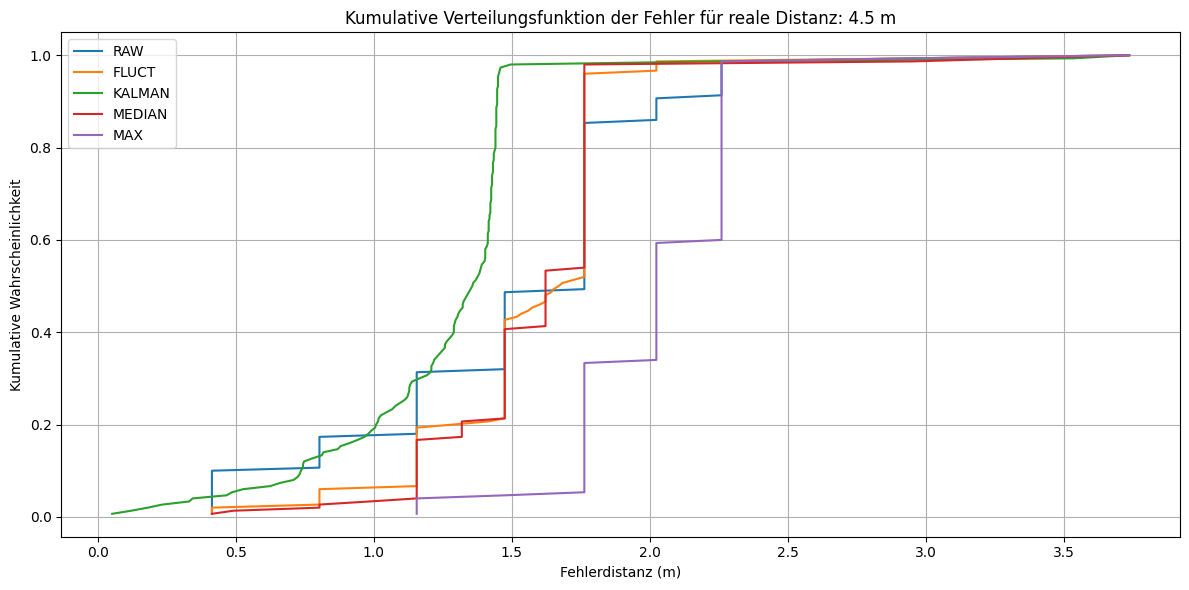

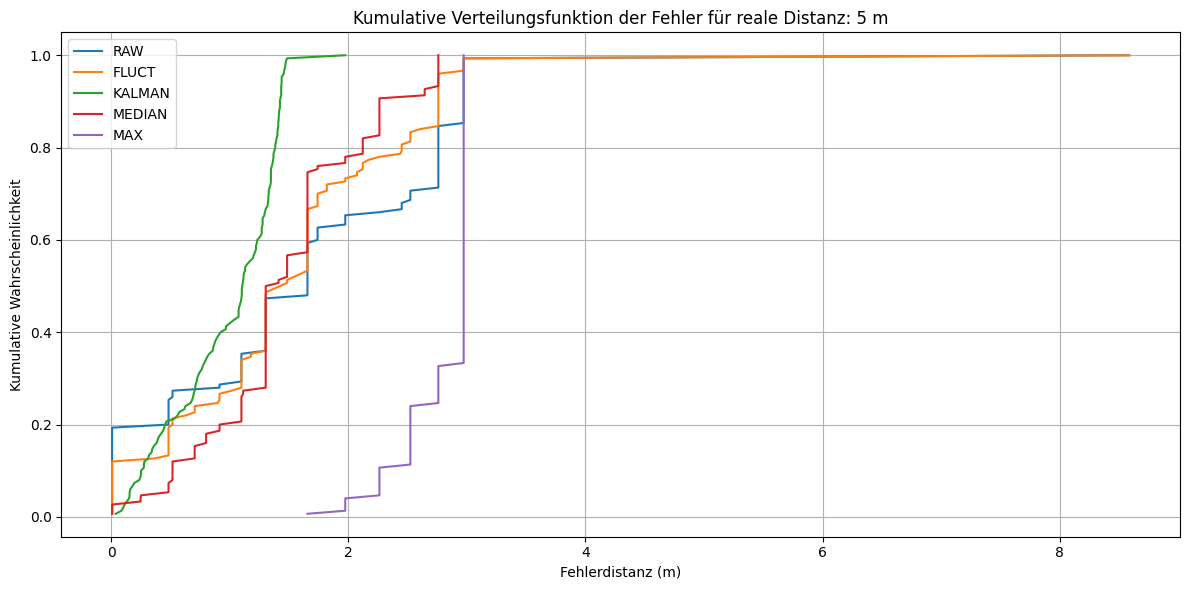

In [62]:
# Fehler-CDF für jede reale Distanz erstellen
for real_distance, distances_estimated in distances_estimated_all.items():
    plt.figure(figsize=(12, 6))

    for filter_name, estimated_distances in distances_estimated.items():
        # Fehler berechnen
        errors = np.abs(np.array(estimated_distances) - real_distance)

        # Fehler sortieren
        sorted_errors = np.sort(errors)

        # CDF-Werte berechnen
        cdf = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors)

        # Plotten der CDF
        plt.plot(sorted_errors, cdf, label=f'{filter_name}', linestyle='-')

    # Achsenbeschriftungen und Titel
    plt.xlabel('Fehlerdistanz (m)')
    plt.ylabel('Kumulative Wahrscheinlichkeit')
    plt.title(f'Kumulative Verteilungsfunktion der Fehler für reale Distanz: {real_distance} m')
    plt.legend()
    plt.grid()
    plt.tight_layout()

    # Diagramm anzeigen
    plt.show()